In [77]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def compute_cohens_kappa(df):
    """
    Compute Cohen's Kappa statistic.
    """
    tp = df['tp']
    fp = df['fp']
    tn = df['tn']
    fn = df['fn']
    total = tp + fp + fn + tn
    if total == 0:
        return 0.0
    observed_agreement = (tp + tn) / total
    expected_agreement = ((tp + fp) * (tp + fn) + (tn + fp) * (tn + fn)) / (total ** 2)
    kappa = (observed_agreement - expected_agreement) / (1 - expected_agreement)
    return kappa

In [78]:
root_dir = "/local/scratch/mikonsta/fednca_journal/workingdir2"
fallback = "/local/scratch/mikonsta/fednca_journal/workingdir55"

In [ ]:
data = "Ultrasound"

if data == "XRay":
    data_name = "XRayMimic200"
    setup = "XRayMimic200_5_42_0.25_full"
    models = ["unet", "segformer", "transunet_b16", "new_mednca"]
elif data == "Ultrasound":
    data_name = "fetalAbdominal"
    setup = "fetalAbdominal_5_42_0.7_full"
    models = ["unet", "segformer", "transunet_b16", "new_mednca"]
elif data == "CRC":
    data_name = "crc"
    setup = "crc_5_42_1.0_full"
    models = ["densenet", "vit4sgd", "maxmednca_nobn"]

In [80]:
os.makedirs(os.path.join(root_dir, setup), exist_ok=True)


results = []
for algorithm in ["ASMR", "FedAvg"]:
    for attack in ["sfa", "ana"]:
        for malf_clients in [[1], [1,2]]:
            for model in models:
                old_name = f"exp_{data_name}_{algorithm}_malf_{attack}_malfclients_{len(malf_clients)}_enc_False_{model}"
                new_name = f"{setup}/exp_{algorithm}_malf_{attack}_malfclients_{'_'.join(map(str, malf_clients))}_none_none_0.0_False_{model}"
                
                old_path = os.path.join(fallback, old_name)
                mid_new_path = os.path.join(fallback, new_name)
                new_path = os.path.join(root_dir, new_name)

                if os.path.exists(new_path):
                    pass  # already exists
                elif os.path.exists(mid_new_path):
                    os.symlink(mid_new_path, new_path)
                elif os.path.exists(old_path):
                    os.symlink(old_path, new_path)
                else:
                    #print(f"Neither {old_path} nor {mid_new_path} exist.")
                    print(f"'--data {data_name} --model {model} --algorithm {algorithm} --malfclients {' --malfclients '.join(map(str, malf_clients))} --malf {attack} --malf_prob 1.0'")
                    continue

                if not os.path.exists(os.path.join(new_path, "dice.txt")):
                    print(f"python ../eval.py --data {data_name} --model {model} --algorithm {algorithm} --malfclients {' --malfclients '.join(map(str, malf_clients))} --malf {attack} --malf_prob 1.0")
                    continue

                score = None
                if data == "Pathology":
                    print(new_path)
                    dice = pd.read_csv(os.path.join(new_path, "dice.txt"), sep='\t', header=None, names=["tp", "fp", "fn", "tn"])
                    score = 2 * dice['tp'] / (2 * dice['tp'] + dice['fp'] + dice['fn'])
                    score = score.loc['val']
                    #score = compute_cohens_kappa(dice.loc['val'])
                    ##accuracy
                    #score = (dice['tp'] + dice['tn']) / (dice['tp'] + dice['tn'] + dice['fp'] + dice['fn'])
                    #score = score.loc['val']
                    #Matthews Correlation Coefficient
                    tp, fp, fn, tn = map(
                        float, dice.loc['val', ['tp', 'fp', 'fn', 'tn']]
                    )
                    numerator = (tp * tn) - (fp * fn)
                    denominator = np.sqrt(tp + fp) * np.sqrt(tp + fn) * np.sqrt(tn + fp) * np.sqrt(tn + fn)
                    if denominator == 0.0:
                        score = 0.0   # or np.nan if you prefer
                    else:
                        score = max(0, numerator / denominator)
                elif data == "CRC":
                    df = pd.read_csv(os.path.join(new_path, "dice.txt"), sep="\t", index_col=0)
                    total = df.values.sum()
                    assert total == 20000
                    correct = np.trace(df.values)
                    score = correct / total
                else:
                    dice = pd.read_csv(os.path.join(new_path, "dice.txt"), sep='\t', header=None, names=["mean", "std"])
                    score = dice.loc['val', 'mean']


                results.append({
                    "algorithm": algorithm,
                    "attack": attack,
                    "malf_clients": len(malf_clients),
                    "model": model,
                    "score": 100 * score
                })


In [81]:
results = pd.DataFrame(results)

In [82]:
results

,algorithm,attack,malf_clients,model,score
0,ASMR,sfa,1,unet,80.099070
1,ASMR,sfa,1,segformer,70.632970
2,ASMR,sfa,1,transunet_b16,81.379712
3,ASMR,sfa,1,new_mednca,79.245758
4,ASMR,sfa,2,unet,76.715446
5,ASMR,sfa,2,segformer,66.287446
6,ASMR,sfa,2,transunet_b16,80.772275
7,ASMR,sfa,2,new_mednca,75.357705
8,ASMR,ana,1,unet,80.196273
9,ASMR,ana,1,segformer,69.534928


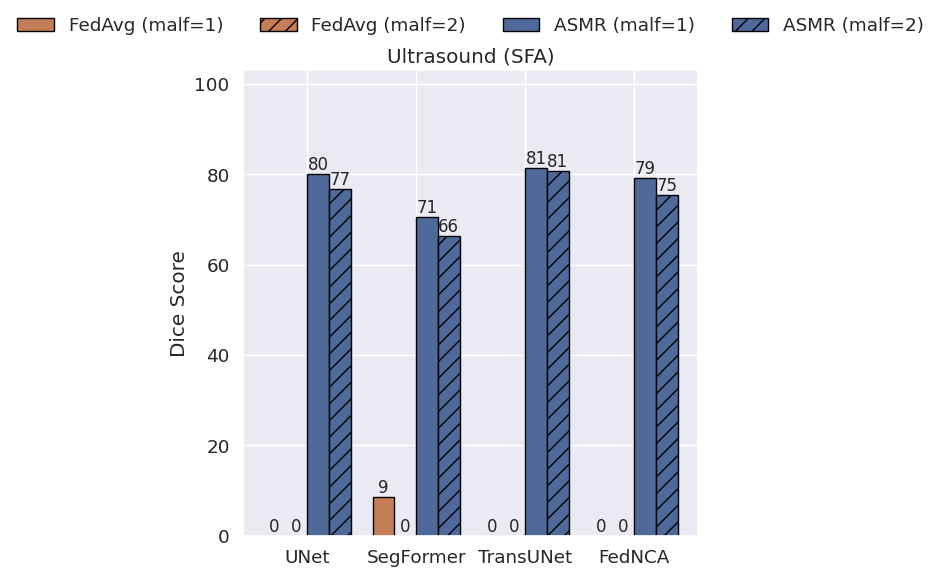

In [84]:
algorithms = ["FedAvg", "ASMR"]
malf_clients = [1, 2]

attack = "SFA"


import numpy as np

df_sfa = results[results["attack"] == attack.lower()]

scores = np.zeros((len(models), len(algorithms) * len(malf_clients)))

col = 0
for alg in algorithms:
    for malf in malf_clients:
        scores[:, col] = (
            df_sfa[
                (df_sfa["algorithm"] == alg) &
                (df_sfa["malf_clients"] == malf)
            ]
            .set_index("model")
            .loc[models, "score"]
            .values
        )
        col += 1


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    font_scale=1.2    # increase overall font size
)

x = np.arange(len(models))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#C57E58", "#C57E58", "#4F6A9A", "#4F6A9A"]
hatches = ["", "//", "", "//"]
labels = [
    "FedAvg (malf=1)",
    "FedAvg (malf=2)",
    "ASMR (malf=1)",
    "ASMR (malf=2)",
]

for i in range(4):
    bars = ax.bar(
        x + (i - 1.5) * bar_width,
        scores[:, i],
        width=bar_width,
        label=labels[i],
        color=colors[i],
        hatch=hatches[i],
        edgecolor="black"
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,              # small offset above bar
            f"{height:.0f}",            # format value
            ha="center",
            va="bottom",
            fontsize=12
        )


# Formatting
ax.set_xticks(x)
if data == "Pathology":
    ax.set_xticklabels(["ResNet18", "ViT", "FedNCA"])
elif data == "CRC":
    ax.set_xticklabels(["DenseNet", "ViT", "FedNCA"])
else:
    ax.set_xticklabels(["UNet", "SegFormer", "TransUNet", "FedNCA"])
    
ax.set_ylabel("MCC Score" if data == "Pathology" else "Dice Score")
if data == "CRC":
    ax.set_title(f"Histopathology ({attack})")
else:
    ax.set_title(f"{data} ({attack})")

plt.ylim(0, 103)
plt.ylabel("Accuracy" if data == "CRC" else "Dice Score")
ax.legend(
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.15)
)

plt.tight_layout()
plt.savefig(f"./plots/malf_results_{data.lower()}_{attack.lower()}.pdf", bbox_inches='tight')